# Programação Dinâmica - LSC (Lenght)

In [ ]:
# 1 - Cria uma matriz para guardar o tamanho da maior subsequência comum até cada posição das duas strings
# 2 - Percorre caractere por caractere das duas strings preenchendo essa matriz
# 3 - Se os caracteres forem iguais, soma 1 ao valor da diagonal da matriz (significa que aumentou a subsequência comum)
# 4 - Se forem diferentes, pega o maior valor entre o de cima ou o da esquerda (mantém a maior subsequência encontrada)
# 5 - Depois de preencher a matriz, faz um "backtracking" do final para o início para reconstruir a subsequência comum
def lcs_length(str1, str2):
    m = len(str1)       # Calcula o tamanho da primeira string
    n = len(str2)       # Calcula o tamanho da segunda string

    # Cria uma matriz (m+1 vs n+1) preenchida com 0
    # A linha 0 e coluna 0 representam string vazia
    matriz = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(1, m + 1):       # Percorre cada caractere da primeira string
        for j in range(1, n + 1):   # Percorre cada caractere da segunda string

            # Verifica se os caracteres atuais são iguais
            # i-1 e j-1 porque a string começa no índice 0
            if str1[i - 1] == str2[j - 1]:

                # Se forem iguais, pega o valor da diagonal da matriz e soma 1
                # isso significa que encontramos mais um caractere comum
                matriz[i][j] = matriz[i - 1][j - 1] + 1
            else:
                # Se forem diferentes, pega o maior valor entre:
                # - o valor de cima
                # - o valor da esquerda
                # pois queremos manter a maior subsequência encontrada até agora
                matriz[i][j] = max(matriz[i - 1][j], matriz[i][j - 1])

    # matriz preenchida e o tamanho das duas strings
    return matriz, m, n

# -------------------------------------------------------------------
# 1 - Começa no canto inferior direito da matriz (onde está o tamanho da LCS)
# 2 - Compara os caracteres atuais das duas strings
# 3 - Se os caracteres forem iguais, adiciona esse caractere na LCS e move na diagonal da matriz
# 4 - Se forem diferentes, move para cima ou para esquerda na matriz seguindo o maior valor
# 5 - Continua até chegar no início da matriz e reconstrói a subsequência comum encontrada
def backtrack_lcs(str1, str2, matriz, m, n):
    # Lista que vai armazenar os caracteres da LCS
    lcs_str = []

    # Começa no canto inferior direito da matriz
    i = m
    j = n

    # Continua enquanto não chegar na primeira linha ou coluna
    while i > 0 and j > 0:

        # Se os caracteres atuais forem iguais
        if str1[i - 1] == str2[j - 1]:

            # Adiciona o caractere na lista da LCS
            lcs_str.append(str1[i - 1])

            # Move na diagonal da matriz (↖)
            i -= 1
            j -= 1

        # Se o valor de cima da matriz for maior
        elif matriz[i - 1][j] > matriz[i][j - 1]:

            # Move para cima na matriz
            i -= 1

        else:
            # Caso contrário move para esquerda
            j -= 1

    # A sequência foi construída ao contrário
    # [::-1] inverte a lista
    # "".join transforma a lista em string
    return "".join(lcs_str[::-1])


# --------------------------------------------
# TESTE DO ALGORITMO
# --------------------------------------------
# Define duas sequências
seq1 = "BDCABA"
seq2 = "ABCBDAB"

# Calcula a matriz da programação dinâmica
matriz_dp, m_len, n_len = lcs_length(seq1, seq2)

# Reconstrói a maior subsequência comum
lcs = backtrack_lcs(seq1, seq2, matriz_dp, m_len, n_len)

# Mostra as sequências originais
print(f"Sequência 1: {seq1}")
print(f"Sequência 2: {seq2}")
print(f"Maior Subsequência Comum (LCS): {lcs}")     # Mostra a LCS encontrada
print(f"Comprimento da LCS: {len(lcs)}")            # Mostra o tamanho da LCS

Sequência 1: BDCABA
Sequência 2: ABCBDAB
Maior Subsequência Comum (LCS): BCBA
Comprimento da LCS: 4


#
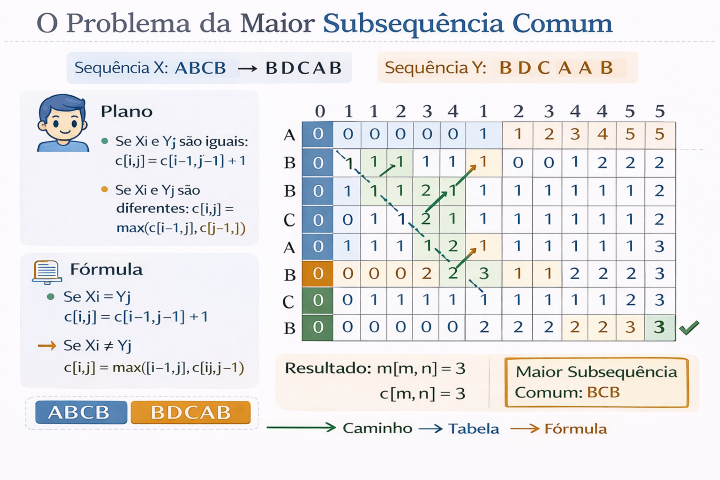